# 🔍 Celda 0: Diagnóstico de GPU

**IMPORTANTE**: Si ves "CUDA disponible: False", necesitas instalar PyTorch con soporte CUDA.

Ejecuta esta celda para diagnosticar el problema.

In [1]:
# Verificar instalación actual de PyTorch
import torch
import subprocess
import sys

print("="*70)
print("🔍 DIAGNÓSTICO DE GPU Y PYTORCH")
print("="*70)

print(f"\n📦 PyTorch versión: {torch.__version__}")
print(f"🐍 Python versión: {sys.version}")

# Verificar CUDA
cuda_available = torch.cuda.is_available()
print(f"\n🎮 CUDA disponible: {cuda_available}")

if cuda_available:
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"✅ CUDA versión: {torch.version.cuda}")
    print(f"💾 Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("❌ GPU NO detectada por PyTorch")
    print("\n🔧 SOLUCIÓN:")
    print("   Necesitas instalar PyTorch con soporte CUDA.")
    print("\n   Ejecuta en una terminal (PowerShell):")
    print("   " + "-"*50)
    # Detectar versión de CUDA recomendada (11.8 o 12.1)
    print("   pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
    print("   " + "-"*50)
    print("\n   O visita: https://pytorch.org/get-started/locally/")
    print("   y selecciona la configuración correcta para tu sistema.")

# Verificar si nvidia-smi está disponible (drivers NVIDIA)
print("\n🖥️ Verificando drivers NVIDIA...")
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, shell=True)
    if result.returncode == 0:
        print("✅ Drivers NVIDIA instalados correctamente")
        # Mostrar solo la primera línea con la versión
        lines = result.stdout.split('\n')
        for line in lines[:3]:
            if line.strip():
                print(f"   {line}")
    else:
        print("⚠️ nvidia-smi no encontrado")
except Exception as e:
    print(f"⚠️ No se pudo ejecutar nvidia-smi: {e}")
    print("   Asegúrate de tener instalados los drivers de NVIDIA")
    print("   Descarga desde: https://www.nvidia.com/download/index.aspx")

print("\n" + "="*70)

🔍 DIAGNÓSTICO DE GPU Y PYTORCH

📦 PyTorch versión: 2.7.1+cu118
🐍 Python versión: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]

🎮 CUDA disponible: True
✅ GPU detectada: NVIDIA GeForce GTX 1650
✅ CUDA versión: 11.8
💾 Memoria GPU: 4.00 GB

🖥️ Verificando drivers NVIDIA...
✅ Drivers NVIDIA instalados correctamente
   Mon Feb  9 16:12:07 2026       
   +-----------------------------------------------------------------------------------------+
   | NVIDIA-SMI 580.88                 Driver Version: 580.88         CUDA Version: 13.0     |



# 🔧 Instalación de PyTorch con CUDA (Si es necesario)

**Solo ejecuta esta sección si la celda anterior mostró "CUDA disponible: False"**

## Pasos para instalar PyTorch con soporte GPU:

### Opción 1: Desde el Notebook (Recomendado)
Ejecuta la siguiente celda para instalar automáticamente PyTorch con CUDA 11.8:

**⚠️ IMPORTANTE**: Después de ejecutar, debes **reiniciar el kernel** del notebook:
1. Menú superior → Kernel → Restart Kernel
2. O tecla rápida

### Opción 2: Desde Terminal
Abre PowerShell y ejecuta:
```bash
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
```

Después de la instalación, vuelve a ejecutar la celda de diagnóstico para verificar.

In [ ]:
# ⚠️ SOLO EJECUTA ESTA CELDA SI CUDA NO ESTÁ DISPONIBLE
# Descomenta las líneas de abajo para instalar

# import sys
# import subprocess

# print("🔄 Desinstalando PyTorch actual...")
# subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])

# print("\n📥 Instalando PyTorch con soporte CUDA 11.8...")
# subprocess.check_call([
#     sys.executable, "-m", "pip", "install", 
#     "torch", "torchvision", "torchaudio",
#     "--index-url", "https://download.pytorch.org/whl/cu118"
# ])

# print("\n✅ Instalación completada!")
# print("🔄 REINICIA EL KERNEL del notebook ahora:")
# print("   Menú → Kernel → Restart Kernel")

print("⚠️ Esta celda está comentada por seguridad.")
print("📝 Lee las instrucciones arriba antes de ejecutar.")

# 🧠 Entrenamiento de CNN con Transfer Learning
## Clasificación de 120 Razas de Perros - Nivel Experto

**Objetivo**: Entrenar una Red Neuronal Convolucional usando Transfer Learning para clasificar razas de perros con >85% accuracy y overfitting <5%

**Arquitectura**: EfficientNetV2 (preentrenada en ImageNet)

**Técnicas aplicadas**:
- Transfer Learning + Fine-tuning
- Data Augmentation agresivo
- Early Stopping
- Learning Rate Scheduling
- Model Checkpointing

# 📦 Celda 1: Importar todas las librerías necesarias

In [2]:
# Librerías básicas
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

# Torchvision para modelos preentrenados
import torchvision.models as models
from torchvision.models import EfficientNet_V2_S_Weights, ResNet50_Weights

# Procesamiento de datos
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Data augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Utilidades
import time
import json
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Usando CPU (el entrenamiento será más lento)")

✅ PyTorch version: 2.7.1+cu118
✅ CUDA disponible: True
✅ GPU: NVIDIA GeForce GTX 1650


# ⚙️ Celda 2: Configuración de hiperparámetros

Aquí definimos todos los parámetros que controlan el entrenamiento. Puedes ajustarlos según tu hardware.

In [3]:
class TrainingConfig:
    # Rutas
    PROJECT_ROOT = Path('../../').resolve()
    MODELS_DIR = PROJECT_ROOT / 'backend' / 'ML' / 'models'
    CHECKPOINTS_DIR = MODELS_DIR / 'checkpoints'
    
    # Datos
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32  # Reduce a 16 si tienes poco RAM/VRAM
    NUM_WORKERS = 0  # 0 para Windows, 4+ para Linux con buena CPU
    
    # Entrenamiento
    EPOCHS = 50  # Máximo de épocas (Early Stopping lo detendrá antes probablemente)
    LEARNING_RATE = 1e-4  # Learning rate inicial para fine-tuning
    WEIGHT_DECAY = 1e-5  # Regularización L2
    
    # Early Stopping
    PATIENCE = 10  # Épocas sin mejora antes de detener
    MIN_DELTA = 0.001  # Mejora mínima considerada significativa
    
    # Modelo
    MODEL_NAME = 'efficientnet_v2_s'  # Opciones: 'efficientnet_v2_s', 'resnet50'
    FREEZE_LAYERS = True  # Congelar capas base al inicio
    UNFREEZE_EPOCH = 10  # Época en la que descongelar para fine-tuning
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Objetivo de performance
    TARGET_ACCURACY = 0.85  # 85% accuracy objetivo
    MAX_OVERFITTING = 0.05  # Máximo 5% de diferencia train-val
    
    def __init__(self):
        # Crear directorios si no existen
        self.MODELS_DIR.mkdir(parents=True, exist_ok=True)
        self.CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

config = TrainingConfig()
print(f"📁 Modelos se guardarán en: {config.MODELS_DIR}")
print(f"💾 Checkpoints en: {config.CHECKPOINTS_DIR}")
print(f"🖥️ Device: {config.DEVICE}")

📁 Modelos se guardarán en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models
💾 Checkpoints en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints
🖥️ Device: cuda


# 📊 Celda 3: Cargar datos preprocesados

Reutilizamos el DataPreprocessor del notebook anterior para cargar y preparar los datos.

In [5]:
# Importar la clase Dataset del notebook 02
class DogBreedDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, img_size=(224, 224)):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.img_size = img_size
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Leer y preprocesar imagen
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.img_size)
        
        # Aplicar transformaciones (augmentation)
        if self.transform:
            image = self.transform(image=image)['image']
            
        return image, label

print("✅ Clase DogBreedDataset definida")

✅ Clase DogBreedDataset definida


# 🎨 Celda 4: Definir Data Augmentation

Usamos **Albumentations** para aplicar transformaciones aleatorias que ayudan a:
- Reducir overfitting
- Hacer el modelo más robusto
- Aumentar artificialmente el tamaño del dataset

In [6]:
def get_training_augmentation():
    """Augmentation agresivo para training"""
    return A.Compose([
        A.Resize(224, 224),
        
        # Transformaciones geométricas
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.2, 
            rotate_limit=30,
            p=0.5
        ),
        A.Perspective(scale=(0.05, 0.1), p=0.3),
        
        # Transformaciones de color/brillo
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),
        A.HueSaturationValue(
            hue_shift_limit=20,
            sat_shift_limit=30,
            val_shift_limit=20,
            p=0.3
        ),
        
        # Efectos de ruido/blur
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0)),
            A.GaussianBlur(blur_limit=(3, 5)),
            A.MotionBlur(blur_limit=5),
        ], p=0.3),
        
        # Normalización con estadísticas de ImageNet
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])

def get_validation_augmentation():
    """Solo resize y normalización para validación/test"""
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])

print("✅ Transformaciones de augmentation definidas")
print("🎯 Training: 9+ transformaciones aleatorias")
print("🔍 Validation: Solo resize + normalización")

✅ Transformaciones de augmentation definidas
🎯 Training: 9+ transformaciones aleatorias
🔍 Validation: Solo resize + normalización


# 📥 Celda 5: Cargar dataset y crear DataLoaders

Cargamos el dataset de Stanford Dogs y lo dividimos en train/val/test usando split estratificado.

In [7]:
import kagglehub

print("📥 Cargando dataset de Stanford Dogs...")
dataset_path = Path(kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset"))
images_path = dataset_path / "images" / "Images"

# Recolectar todas las imágenes y etiquetas
image_paths = []
breed_names = []

for breed_folder in images_path.iterdir():
    if breed_folder.is_dir():
        breed_name = breed_folder.name.split('-')[-1]
        for img_path in breed_folder.glob("*.jpg"):
            image_paths.append(img_path)
            breed_names.append(breed_name)

print(f"✅ Total de imágenes encontradas: {len(image_paths)}")

# Codificar etiquetas
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(breed_names)
num_classes = len(label_encoder.classes_)

print(f"✅ Número de razas (clases): {num_classes}")

# Guardar label encoder para usar en producción
encoder_path = config.MODELS_DIR / 'label_encoder.pkl'
joblib.dump(label_encoder, encoder_path)
print(f"💾 Label encoder guardado en: {encoder_path}")

📥 Cargando dataset de Stanford Dogs...
✅ Total de imágenes encontradas: 20580
✅ Número de razas (clases): 119
💾 Label encoder guardado en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\label_encoder.pkl


In [8]:
# Split estratificado: 70% train, 15% val, 15% test
print("🔀 Dividiendo dataset en train/val/test...")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels_encoded,
    test_size=0.3,
    stratify=labels_encoded,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(f"📊 División completada:")
print(f"   🎯 Train: {len(train_paths)} imágenes ({len(train_paths)/len(image_paths)*100:.1f}%)")
print(f"   🔍 Validation: {len(val_paths)} imágenes ({len(val_paths)/len(image_paths)*100:.1f}%)")
print(f"   📈 Test: {len(test_paths)} imágenes ({len(test_paths)/len(image_paths)*100:.1f}%)")

🔀 Dividiendo dataset en train/val/test...
📊 División completada:
   🎯 Train: 14406 imágenes (70.0%)
   🔍 Validation: 3087 imágenes (15.0%)
   📈 Test: 3087 imágenes (15.0%)


In [9]:
# Crear datasets con augmentation
print("🎨 Creando datasets con augmentation...")

train_dataset = DogBreedDataset(
    train_paths, 
    train_labels,
    transform=get_training_augmentation(),
    img_size=config.IMG_SIZE
)

val_dataset = DogBreedDataset(
    val_paths,
    val_labels,
    transform=get_validation_augmentation(),
    img_size=config.IMG_SIZE
)

test_dataset = DogBreedDataset(
    test_paths,
    test_labels,
    transform=get_validation_augmentation(),
    img_size=config.IMG_SIZE
)

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print("✅ DataLoaders creados:")
print(f"   🎯 Train batches: {len(train_loader)}")
print(f"   🔍 Val batches: {len(val_loader)}")
print(f"   📈 Test batches: {len(test_loader)}")

🎨 Creando datasets con augmentation...
✅ DataLoaders creados:
   🎯 Train batches: 451
   🔍 Val batches: 97
   📈 Test batches: 97


# 🏗️ Celda 6: Crear modelo con Transfer Learning

Usamos **EfficientNetV2-S** preentrenado en ImageNet y adaptamos la última capa para 120 clases (razas).

In [10]:
def create_model(num_classes, model_name='efficientnet_v2_s', freeze_layers=True):
    """
    Crea modelo con Transfer Learning
    
    Args:
        num_classes: Número de clases de salida (120 razas)
        model_name: 'efficientnet_v2_s' o 'resnet50'
        freeze_layers: Si True, congela capas base para transfer learning
    """
    print(f"🏗️ Creando modelo: {model_name}")
    
    if model_name == 'efficientnet_v2_s':
        # Cargar EfficientNetV2-S con pesos preentrenados
        weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
        model = models.efficientnet_v2_s(weights=weights)
        
        # Congelar capas base si es necesario
        if freeze_layers:
            for param in model.features.parameters():
                param.requires_grad = False
            print("🔒 Capas base congeladas (Transfer Learning)")
        
        # Adaptar clasificador para 120 clases
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
        
    elif model_name == 'resnet50':
        # Alternativa: ResNet50
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        
        if freeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            print("🔒 Capas base congeladas (Transfer Learning)")
        
        # Adaptar última capa
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
    
    return model

# Crear modelo
model = create_model(
    num_classes=num_classes,
    model_name=config.MODEL_NAME,
    freeze_layers=config.FREEZE_LAYERS
)

# Mover a GPU/CPU
model = model.to(config.DEVICE)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Modelo creado y movido a {config.DEVICE}")
print(f"📊 Parámetros totales: {total_params:,}")
print(f"🎯 Parámetros entrenables: {trainable_params:,}")
print(f"🔒 Parámetros congelados: {total_params - trainable_params:,}")

🏗️ Creando modelo: efficientnet_v2_s
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\yeder/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 113MB/s]


🔒 Capas base congeladas (Transfer Learning)
✅ Modelo creado y movido a cuda
📊 Parámetros totales: 20,894,407
🎯 Parámetros entrenables: 716,919
🔒 Parámetros congelados: 20,177,488


# 🎯 Celda 7: Definir Loss Function, Optimizer y Scheduler

- **Loss**: CrossEntropyLoss (estándar para clasificación multiclase)
- **Optimizer**: AdamW (Adam con weight decay mejorado)
- **Scheduler**: ReduceLROnPlateau (reduce LR cuando el val_loss deja de mejorar)

In [12]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - Solo entrena parámetros que requieren gradientes
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning Rate Scheduler - Reduce LR cuando val_loss no mejora
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,  # Reduce LR a la mitad
    patience=5,   # Espera 5 épocas sin mejora
    min_lr=1e-7
)

print("✅ Configuración de entrenamiento:")
print(f"   📉 Loss: CrossEntropyLoss")
print(f"   🎯 Optimizer: AdamW (lr={config.LEARNING_RATE}, wd={config.WEIGHT_DECAY})")
print(f"   📊 Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

✅ Configuración de entrenamiento:
   📉 Loss: CrossEntropyLoss
   🎯 Optimizer: AdamW (lr=0.0001, wd=1e-05)
   📊 Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


# 🔧 Celda 8: Funciones auxiliares de entrenamiento

Funciones para entrenar y validar el modelo en cada época.

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """
    Entrena el modelo por una época
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training', leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Métricas
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Actualizar progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """
    Valida el modelo en el conjunto de validación
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation', leave=False)
        
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


print("✅ Funciones de entrenamiento y validación definidas")

✅ Funciones de entrenamiento y validación definidas


# 🚀 Celda 9: Training Loop Principal

Loop de entrenamiento con:
- Early Stopping
- Model Checkpointing
- Unfreezing para Fine-tuning
- Tracking de métricas

In [14]:
# Variables para tracking
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_val_loss = float('inf')
patience_counter = 0
start_time = time.time()

print("🚀 Iniciando entrenamiento...")
print(f"📊 Épocas máximas: {config.EPOCHS}")
print(f"⏱️ Patience: {config.PATIENCE} épocas")
print(f"🎯 Objetivo: Accuracy >{config.TARGET_ACCURACY*100}%, Overfitting <{config.MAX_OVERFITTING*100}%")
print("="*70)

for epoch in range(config.EPOCHS):
    epoch_start = time.time()
    
    # Descongelar capas para fine-tuning después de X épocas
    if epoch == config.UNFREEZE_EPOCH and config.FREEZE_LAYERS:
        print(f"\n🔓 Época {epoch+1}: Descongelando capas base para fine-tuning...")
        for param in model.parameters():
            param.requires_grad = True
        
        # Recrear optimizer con todos los parámetros
        optimizer = optim.AdamW(
            model.parameters(),
            lr=config.LEARNING_RATE / 10,  # LR más bajo para fine-tuning
            weight_decay=config.WEIGHT_DECAY
        )
        print(f"✅ Todos los parámetros ahora entrenables (LR reducido a {config.LEARNING_RATE/10})\n")
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, config.DEVICE
    )
    
    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, config.DEVICE
    )
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Guardar historia
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Calcular overfitting
    overfitting = train_acc - val_acc
    
    # Tiempo de época
    epoch_time = time.time() - epoch_start
    
    # Print resultados
    print(f"\nÉpoca [{epoch+1}/{config.EPOCHS}] ({epoch_time:.1f}s):")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    print(f"  Overfitting: {overfitting*100:.2f}% | LR: {current_lr:.2e}")
    
    # Model checkpointing - Guardar mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0
        
        # Guardar modelo
        checkpoint_path = config.CHECKPOINTS_DIR / 'best_model.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'num_classes': num_classes,
            'model_name': config.MODEL_NAME
        }, checkpoint_path)
        
        print(f"  ✅ MEJOR MODELO guardado! Val Acc: {val_acc*100:.2f}%")
        
        # Verificar si alcanzamos el objetivo
        if val_acc >= config.TARGET_ACCURACY and overfitting <= config.MAX_OVERFITTING:
            print(f"\n🎉 ¡OBJETIVO ALCANZADO!")
            print(f"   Accuracy: {val_acc*100:.2f}% (objetivo: >{config.TARGET_ACCURACY*100}%)")
            print(f"   Overfitting: {overfitting*100:.2f}% (objetivo: <{config.MAX_OVERFITTING*100}%)")
    else:
        patience_counter += 1
        print(f"  ⏳ Sin mejora. Patience: {patience_counter}/{config.PATIENCE}")
    
    print("="*70)
    
    # Early Stopping
    if patience_counter >= config.PATIENCE:
        print(f"\n🛑 Early Stopping activado después de {epoch+1} épocas")
        print(f"   Mejor Val Acc: {best_val_acc*100:.2f}% (Época {epoch+1-patience_counter})")
        break

# Tiempo total
total_time = time.time() - start_time
print(f"\n⏱️ Entrenamiento completado en {total_time/60:.1f} minutos")
print(f"🏆 Mejor Val Accuracy: {best_val_acc*100:.2f}%")
print(f"📉 Mejor Val Loss: {best_val_loss:.4f}")

🚀 Iniciando entrenamiento...
📊 Épocas máximas: 50
⏱️ Patience: 10 épocas
🎯 Objetivo: Accuracy >85.0%, Overfitting <5.0%


Training:   0%|          | 0/451 [00:00<?, ?it/s]

Validation:   0%|          | 0/97 [00:00<?, ?it/s]


Época [1/50] (329.4s):
  Train Loss: 4.2761 | Train Acc: 26.07%
  Val Loss:   3.4612 | Val Acc:   73.40%
  Overfitting: -47.33% | LR: 1.00e-04
  ✅ MEJOR MODELO guardado! Val Acc: 73.40%


Training:   0%|          | 0/451 [00:00<?, ?it/s]

...

Training:   0%|          | 0/451 [00:00<?, ?it/s]

Validation:   0%|          | 0/97 [00:00<?, ?it/s]


Época [20/50] (3118.2s):
  Train Loss: 0.6622 | Train Acc: 80.60%
  Val Loss:   0.3487 | Val Acc:   89.50%
  Overfitting: -8.91% | LR: 1.00e-05
  ✅ MEJOR MODELO guardado! Val Acc: 89.50%

🎉 ¡OBJETIVO ALCANZADO!
   Accuracy: 89.50% (objetivo: >85.0%)
   Overfitting: -8.91% (objetivo: <5.0%)


Training:   0%|          | 0/451 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 📊 Celda 10: Visualizar curvas de entrenamiento

Gráficos de Loss y Accuracy durante el entrenamiento.

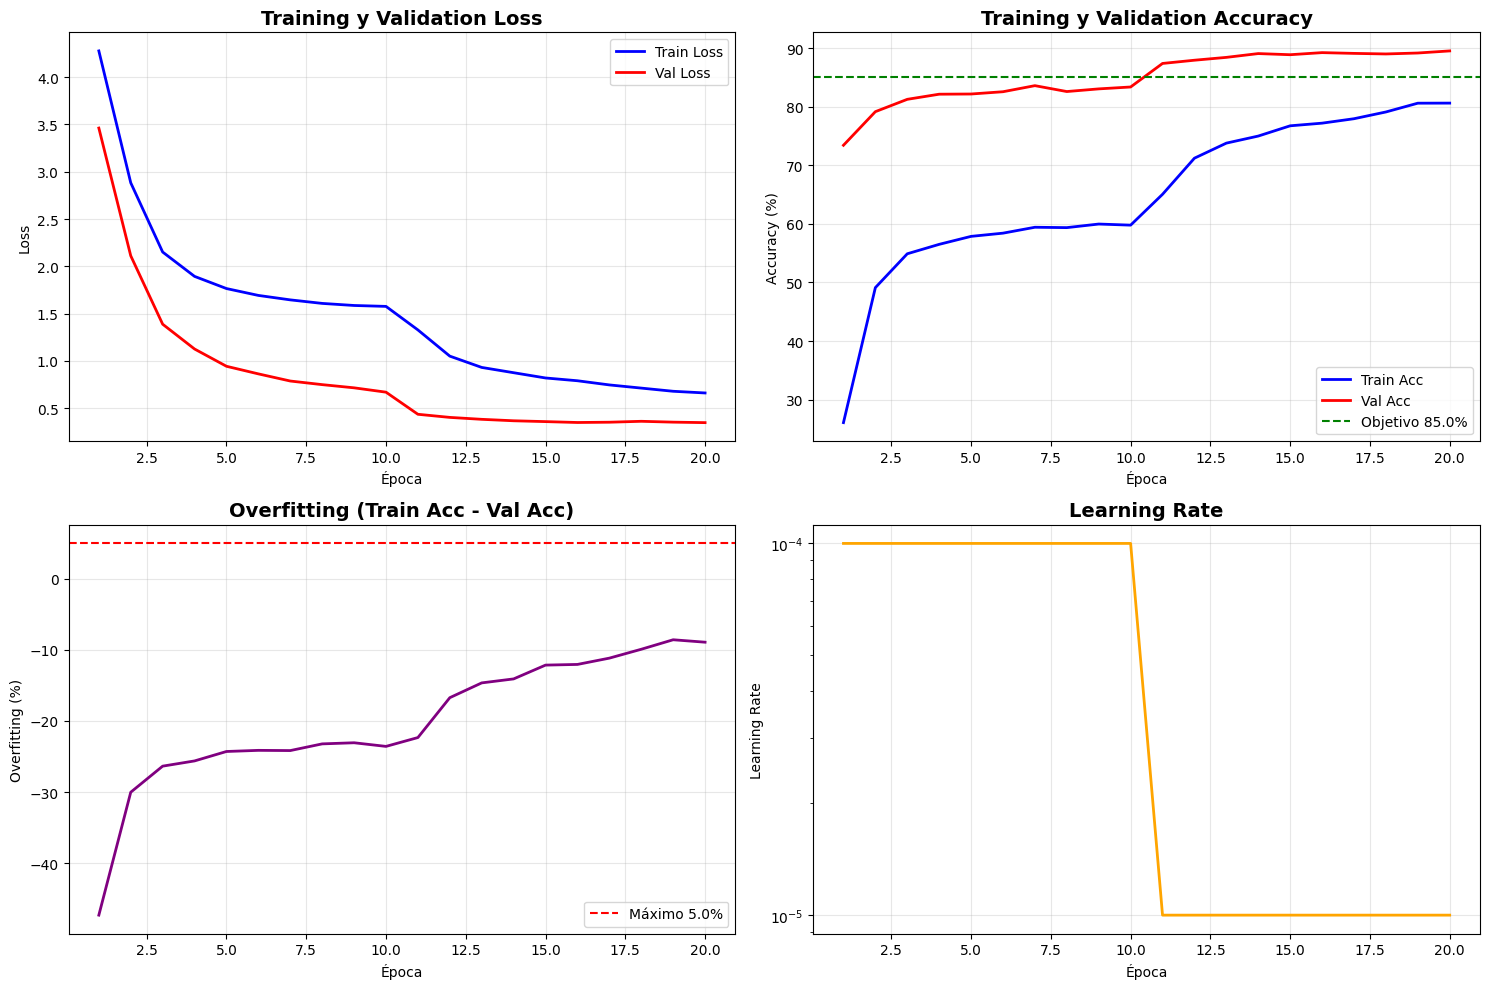

✅ Gráficos guardados en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\training_curves.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_title('Training y Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, [acc*100 for acc in history['train_acc']], 'b-', label='Train Acc', linewidth=2)
axes[0, 1].plot(epochs_range, [acc*100 for acc in history['val_acc']], 'r-', label='Val Acc', linewidth=2)
axes[0, 1].axhline(y=config.TARGET_ACCURACY*100, color='g', linestyle='--', label=f'Objetivo {config.TARGET_ACCURACY*100}%')
axes[0, 1].set_title('Training y Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Overfitting
overfitting_per_epoch = [(train - val)*100 for train, val in zip(history['train_acc'], history['val_acc'])]
axes[1, 0].plot(epochs_range, overfitting_per_epoch, 'purple', linewidth=2)
axes[1, 0].axhline(y=config.MAX_OVERFITTING*100, color='r', linestyle='--', label=f'Máximo {config.MAX_OVERFITTING*100}%')
axes[1, 0].set_title('Overfitting (Train Acc - Val Acc)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Overfitting (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history['lr'], 'orange', linewidth=2)
axes[1, 1].set_title('Learning Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.CHECKPOINTS_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Gráficos guardados en: {config.CHECKPOINTS_DIR / 'training_curves.png'}")

# 💾 Celda 11: Guardar modelo final para producción

Guardamos el mejor modelo en formato listo para usar en el backend.

In [16]:
# Cargar el mejor modelo
checkpoint = torch.load(config.CHECKPOINTS_DIR / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Guardar modelo completo para producción
production_model_path = config.MODELS_DIR / 'dog_breed_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes,
    'model_name': config.MODEL_NAME,
    'val_acc': checkpoint['val_acc'],
    'val_loss': checkpoint['val_loss'],
    'img_size': config.IMG_SIZE,
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225]
    }
}, production_model_path)

print(f"✅ Modelo de producción guardado en: {production_model_path}")
print(f"📊 Val Accuracy: {checkpoint['val_acc']*100:.2f}%")
print(f"📉 Val Loss: {checkpoint['val_loss']:.4f}")

# Guardar historial de entrenamiento
history_path = config.CHECKPOINTS_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    # Convertir a formato serializable
    serializable_history = {
        'train_loss': [float(x) for x in history['train_loss']],
        'train_acc': [float(x) for x in history['train_acc']],
        'val_loss': [float(x) for x in history['val_loss']],
        'val_acc': [float(x) for x in history['val_acc']],
        'lr': [float(x) for x in history['lr']],
        'best_val_acc': float(best_val_acc),
        'best_val_loss': float(best_val_loss)
    }
    json.dump(serializable_history, f, indent=2)

print(f"💾 Historial guardado en: {history_path}")

✅ Modelo de producción guardado en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\dog_breed_model.pth
📊 Val Accuracy: 89.50%
📉 Val Loss: 0.3487
💾 Historial guardado en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\training_history.json


# 🧪 Celda 12: Evaluar en Test Set

Evaluamos el modelo final en el conjunto de test (datos nunca vistos).

In [17]:
print("🧪 Evaluando modelo en Test Set...\n")

model.eval()
all_predictions = []
all_labels = []
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(config.DEVICE)
        labels = labels.to(config.DEVICE)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total

print(f"\n{'='*70}")
print(f"🏆 RESULTADOS FINALES EN TEST SET")
print(f"{'='*70}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Imágenes correctas: {test_correct}/{test_total}")

# Verificar si cumple con los objetivos
train_acc_final = history['train_acc'][-1]
val_acc_final = history['val_acc'][-1]
overfitting_final = (train_acc_final - val_acc_final)

print(f"\n📊 Verificación de objetivos:")
if test_accuracy >= config.TARGET_ACCURACY:
    print(f"✅ Accuracy objetivo alcanzado: {test_accuracy*100:.2f}% >= {config.TARGET_ACCURACY*100}%")
else:
    print(f"❌ Accuracy por debajo del objetivo: {test_accuracy*100:.2f}% < {config.TARGET_ACCURACY*100}%")

if overfitting_final <= config.MAX_OVERFITTING:
    print(f"✅ Overfitting bajo control: {overfitting_final*100:.2f}% <= {config.MAX_OVERFITTING*100}%")
else:
    print(f"⚠️ Overfitting alto: {overfitting_final*100:.2f}% > {config.MAX_OVERFITTING*100}%")

print(f"{'='*70}")

🧪 Evaluando modelo en Test Set...



Testing:   0%|          | 0/97 [00:00<?, ?it/s]


🏆 RESULTADOS FINALES EN TEST SET
Test Accuracy: 90.22%
Imágenes correctas: 2785/3087

📊 Verificación de objetivos:
✅ Accuracy objetivo alcanzado: 90.22% >= 85.0%
✅ Overfitting bajo control: -8.91% <= 5.0%


# 📈 Celda 13: Matriz de confusión (Top 20 razas)

Para las 20 razas más frecuentes, visualizamos la matriz de confusión.

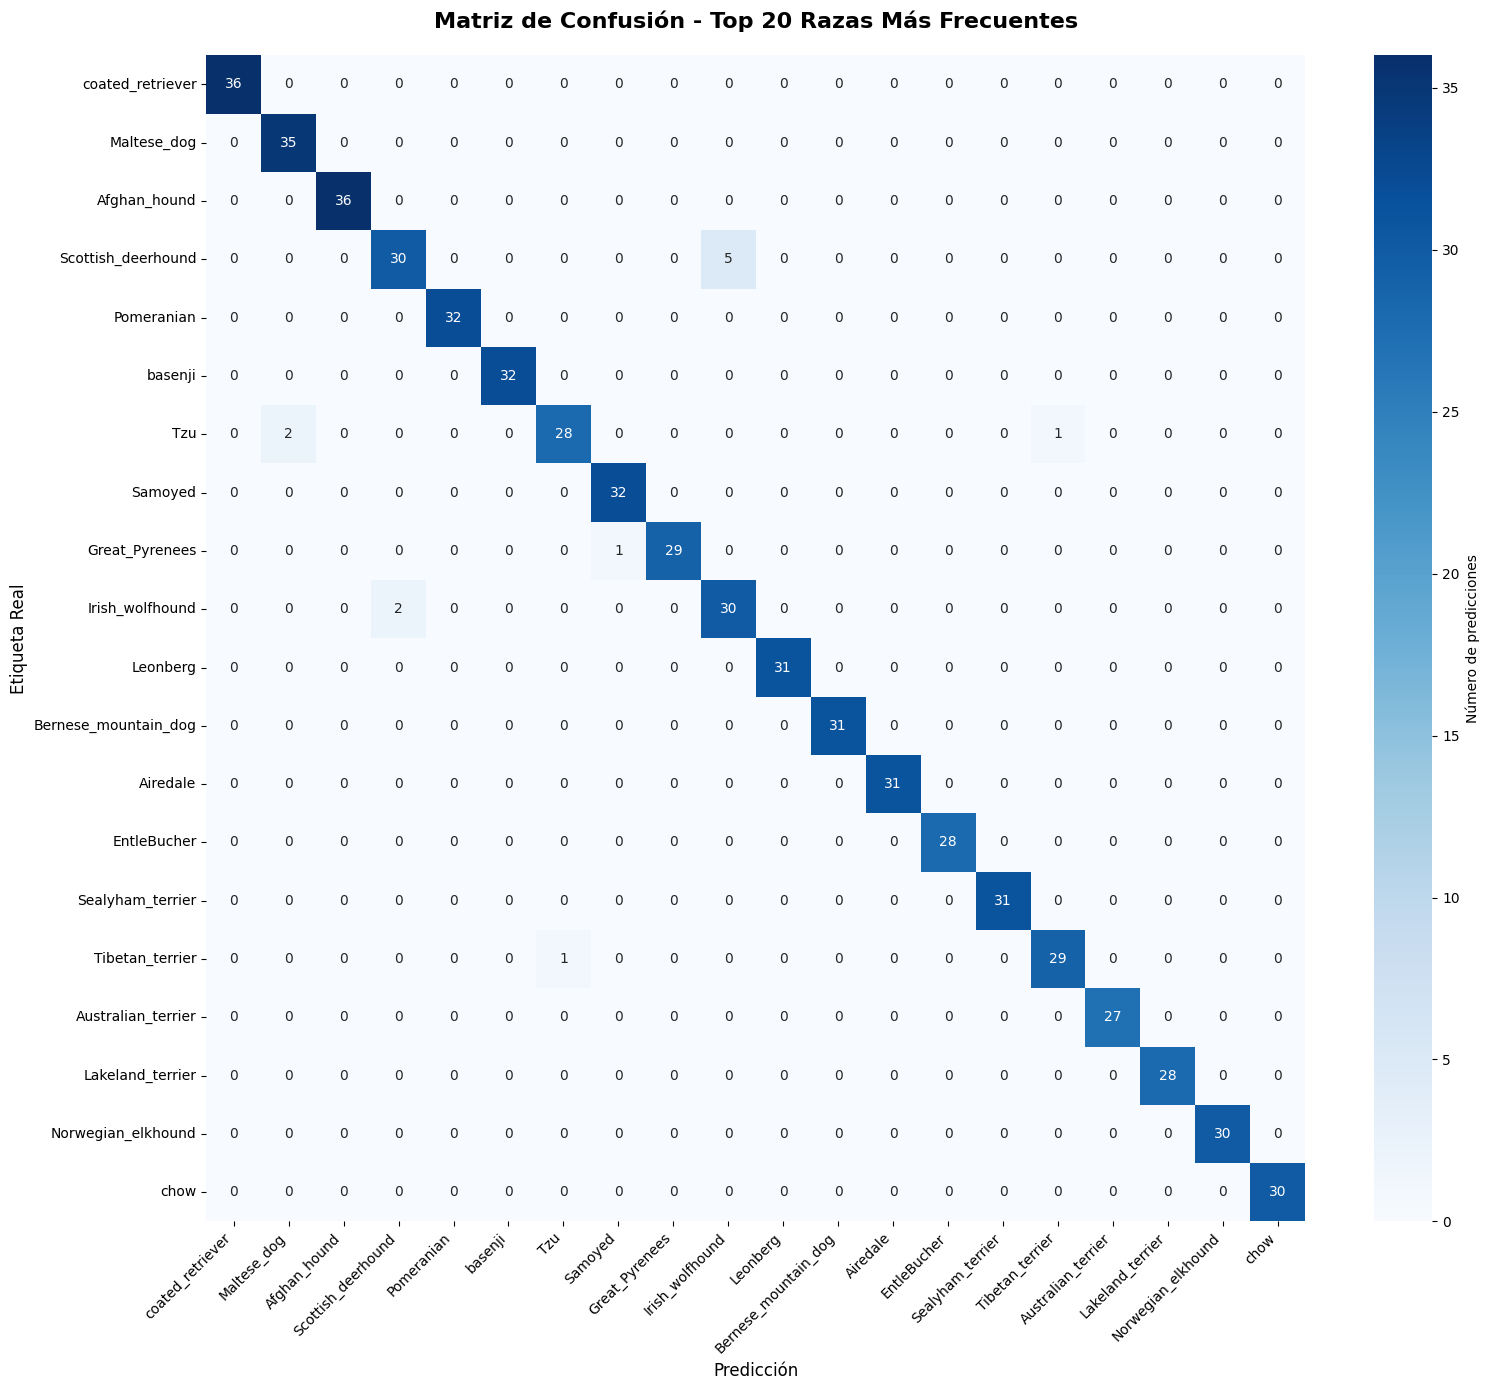

✅ Matriz de confusión guardada en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\confusion_matrix_top20.png


In [18]:
# Calcular matriz de confusión completa
cm = confusion_matrix(all_labels, all_predictions)

# Seleccionar top 20 clases más frecuentes
unique_labels, counts = np.unique(all_labels, return_counts=True)
top20_indices = np.argsort(counts)[-20:][::-1]
top20_classes = unique_labels[top20_indices]

# Filtrar matriz de confusión para top 20
cm_top20 = cm[top20_classes][:, top20_classes]
class_names_top20 = label_encoder.inverse_transform(top20_classes)

# Visualizar
plt.figure(figsize=(16, 14))
sns.heatmap(cm_top20, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_top20, 
            yticklabels=class_names_top20,
            cbar_kws={'label': 'Número de predicciones'})
plt.title('Matriz de Confusión - Top 20 Razas Más Frecuentes', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(config.CHECKPOINTS_DIR / 'confusion_matrix_top20.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Matriz de confusión guardada en: {config.CHECKPOINTS_DIR / 'confusion_matrix_top20.png'}")

# 📋 Celda 14: Classification Report detallado

Precision, Recall y F1-Score por cada raza.

In [19]:
# Classification report completo
report = classification_report(
    all_labels, 
    all_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

# Convertir a DataFrame para mejor visualización
report_df = pd.DataFrame(report).transpose()

# Guardar report completo
report_path = config.CHECKPOINTS_DIR / 'classification_report.csv'
report_df.to_csv(report_path)
print(f"💾 Classification report guardado en: {report_path}")

# Mostrar métricas globales
print("\n📊 MÉTRICAS GLOBALES:")
print(f"{'='*50}")
print(f"Accuracy:  {report['accuracy']*100:.2f}%")
print(f"Precision (macro): {report['macro avg']['precision']*100:.2f}%")
print(f"Recall (macro):    {report['macro avg']['recall']*100:.2f}%")
print(f"F1-Score (macro):  {report['macro avg']['f1-score']*100:.2f}%")
print(f"{'='*50}")

# Top 10 mejor clasificadas
breed_scores = report_df.iloc[:-3]  # Excluir filas de promedio
breed_scores = breed_scores[breed_scores['support'] > 10]  # Filtrar razas con >10 muestras
top10_breeds = breed_scores.nlargest(10, 'f1-score')

print("\n🏆 TOP 10 RAZAS MEJOR CLASIFICADAS (F1-Score):")
print(f"{'='*70}")
for idx, (breed, row) in enumerate(top10_breeds.iterrows(), 1):
    print(f"{idx:2d}. {breed:25s} - F1: {row['f1-score']*100:5.2f}% (Support: {int(row['support'])})")

# Bottom 10 peor clasificadas
bottom10_breeds = breed_scores.nsmallest(10, 'f1-score')

print(f"\n⚠️ TOP 10 RAZAS CON MENOR F1-Score:")
print(f"{'='*70}")
for idx, (breed, row) in enumerate(bottom10_breeds.iterrows(), 1):
    print(f"{idx:2d}. {breed:25s} - F1: {row['f1-score']*100:5.2f}% (Support: {int(row['support'])})")

💾 Classification report guardado en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\classification_report.csv

📊 MÉTRICAS GLOBALES:
Accuracy:  90.22%
Precision (macro): 90.31%
Recall (macro):    89.95%
F1-Score (macro):  89.84%

🏆 TOP 10 RAZAS MEJOR CLASIFICADAS (F1-Score):
 1. Afghan_hound              - F1: 100.00% (Support: 36)
 2. African_hunting_dog       - F1: 100.00% (Support: 25)
 3. Gordon_setter             - F1: 100.00% (Support: 23)
 4. Pekinese                  - F1: 100.00% (Support: 22)
 5. Welsh_springer_spaniel    - F1: 100.00% (Support: 22)
 6. chow                      - F1: 100.00% (Support: 30)
 7. Pomeranian                - F1: 98.46% (Support: 33)
 8. Samoyed                   - F1: 98.46% (Support: 32)
 9. basenji                   - F1: 98.46% (Support: 32)
10. Sealyham_terrier          - F1: 98.41% (Support: 31)

⚠️ TOP 10 RAZAS CON MENOR F1-Score:
 1. Eskimo_dog                - F1: 26.67% (Support: 22)
 2. miniature_

# 🎨 Celda 15: Probar predicciones individuales

Probamos el modelo con algunas imágenes aleatorias del test set.

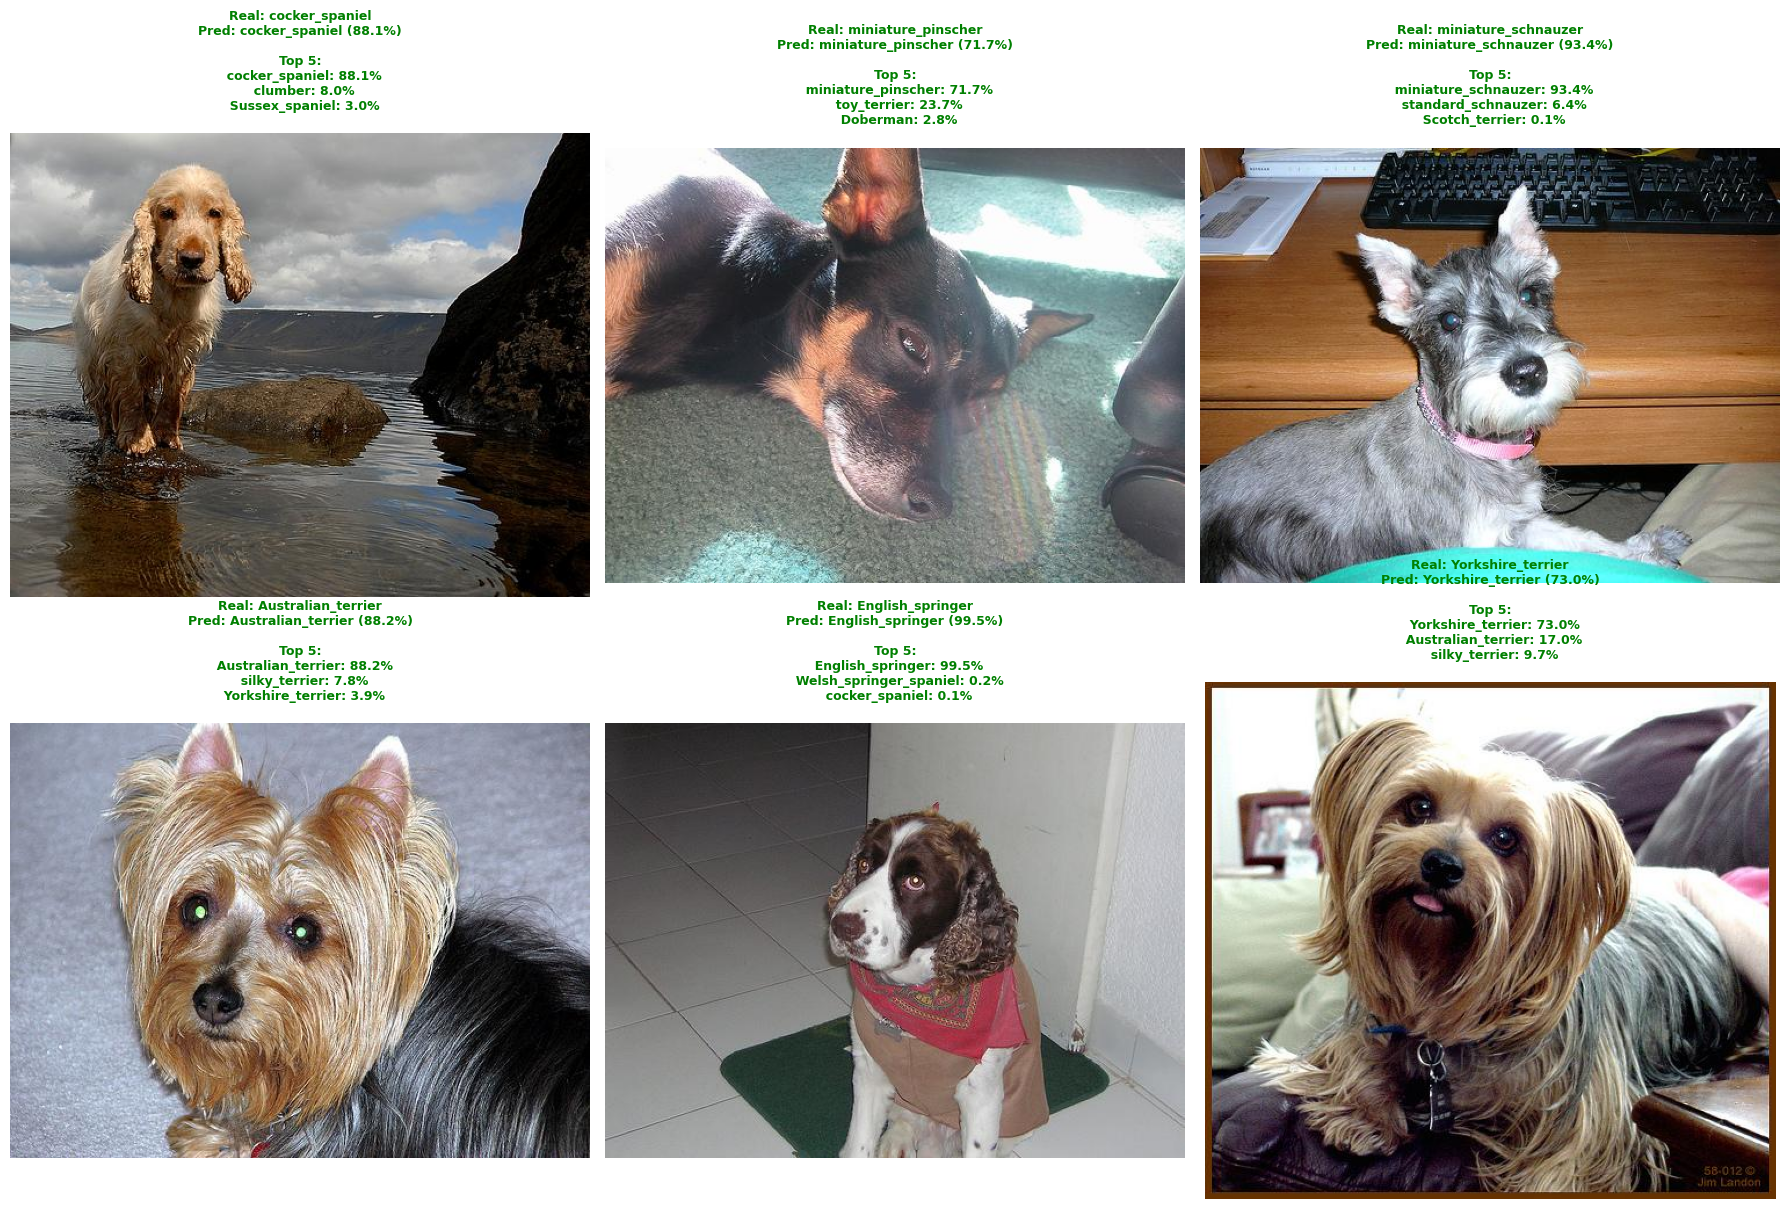

✅ Predicciones de muestra guardadas en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\sample_predictions.png


In [20]:
def predict_image(model, image_path, label_encoder, device, transform):
    """
    Predice la raza de un perro dada una imagen
    Retorna top-5 predicciones con probabilidades
    """
    # Cargar y preprocesar imagen
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, (224, 224))
    
    # Aplicar transformaciones
    transformed = transform(image=image_resized)['image']
    transformed = transformed.unsqueeze(0).to(device)
    
    # Predicción
    model.eval()
    with torch.no_grad():
        outputs = model(transformed)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top5_prob, top5_idx = torch.topk(probabilities, 5)
    
    # Convertir a nombres de razas
    top5_breeds = label_encoder.inverse_transform(top5_idx.cpu().numpy()[0])
    top5_probs = top5_prob.cpu().numpy()[0]
    
    return image_rgb, top5_breeds, top5_probs


# Probar con 6 imágenes aleatorias
val_transform = get_validation_augmentation()
random_indices = np.random.choice(len(test_paths), 6, replace=False)
random_test_paths = [test_paths[i] for i in random_indices]
random_test_labels = [test_labels[i] for i in random_indices]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (img_path, true_label) in enumerate(zip(random_test_paths, random_test_labels)):
    image, top5_breeds, top5_probs = predict_image(
        model, img_path, label_encoder, config.DEVICE, val_transform
    )
    
    # Mostrar imagen
    axes[idx].imshow(image)
    axes[idx].axis('off')
    
    # Título con predicción
    true_breed = label_encoder.inverse_transform([true_label])[0]
    pred_breed = top5_breeds[0]
    confidence = top5_probs[0] * 100
    
    is_correct = (pred_breed == true_breed)
    color = 'green' if is_correct else 'red'
    
    title = f"Real: {true_breed}\n"
    title += f"Pred: {pred_breed} ({confidence:.1f}%)\n"
    title += "\nTop 5:\n"
    for breed, prob in zip(top5_breeds[:3], top5_probs[:3]):
        title += f"  {breed}: {prob*100:.1f}%\n"
    
    axes[idx].set_title(title, fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(config.CHECKPOINTS_DIR / 'sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Predicciones de muestra guardadas en: {config.CHECKPOINTS_DIR / 'sample_predictions.png'}")

# 📝 Celda 16: Resumen final y próximos pasos

Resumen de lo logrado y qué hacer a continuación.

In [21]:
print("\n" + "="*70)
print("🎉 ENTRENAMIENTO COMPLETADO - RESUMEN FINAL")
print("="*70)

print(f"\n📊 MÉTRICAS FINALES:")
print(f"   Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   Train Accuracy (final): {history['train_acc'][-1]*100:.2f}%")
print(f"   Overfitting: {overfitting_final*100:.2f}%")

print(f"\n💾 ARCHIVOS GENERADOS:")
print(f"   Modelo de producción: {config.MODELS_DIR / 'dog_breed_model.pth'}")
print(f"   Label encoder: {config.MODELS_DIR / 'label_encoder.pkl'}")
print(f"   Mejor checkpoint: {config.CHECKPOINTS_DIR / 'best_model.pth'}")
print(f"   Training history: {config.CHECKPOINTS_DIR / 'training_history.json'}")
print(f"   Classification report: {config.CHECKPOINTS_DIR / 'classification_report.csv'}")

print(f"\n📈 VISUALIZACIONES:")
print(f"   Curvas de entrenamiento: {config.CHECKPOINTS_DIR / 'training_curves.png'}")
print(f"   Matriz de confusión: {config.CHECKPOINTS_DIR / 'confusion_matrix_top20.png'}")
print(f"   Predicciones de muestra: {config.CHECKPOINTS_DIR / 'sample_predictions.png'}")

print(f"\n🚀 PRÓXIMOS PASOS:")
print(f"   1. ✅ Crear notebook 04_evaluation.ipynb para análisis más profundo")
print(f"   2. ✅ Implementar backend/app/services/ml_service.py para cargar el modelo")
print(f"   3. ✅ Crear API endpoints en FastAPI para predicciones")
print(f"   4. ✅ Desarrollar frontend React con upload de imágenes")
print(f"   5. ✅ Implementar sistema de feedback y reentrenamiento")
print(f"   6. ✅ A/B Testing y monitoreo de Data Drift")
print(f"   7. ✅ Dockerización y deploy en cloud")

print("\n" + "="*70)
print("💪 ¡Modelo entrenado exitosamente! Listo para producción.")
print("="*70 + "\n")


🎉 ENTRENAMIENTO COMPLETADO - RESUMEN FINAL

📊 MÉTRICAS FINALES:
   Best Validation Accuracy: 89.50%
   Test Accuracy: 90.22%
   Train Accuracy (final): 80.60%
   Overfitting: -8.91%

💾 ARCHIVOS GENERADOS:
   Modelo de producción: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\dog_breed_model.pth
   Label encoder: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\label_encoder.pkl
   Mejor checkpoint: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\best_model.pth
   Training history: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\training_history.json
   Classification report: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\classification_report.csv

📈 VISUALIZACIONES:
   Curvas de entrenamiento: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\checkpoints\training_curves.png
   Matriz 